<a href="https://colab.research.google.com/github/Baranetharan-ds/Datascience-bootcamp/blob/main/Linear_Regression_Car_Price_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Univariate Linear REgression (1 ip - 1 op) education -> salary
- Multivariate REgression (2 or more ip - 1 op) experience, education, sports -> salary
- Linear Regression (straight line)
- Polynomial Regression (uni or multi)
- y = m1x + c

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/nunnarilabs/ml/master/automobileEDA.csv")

In [ ]:
# df = pd.read_csv("https://raw.githubusercontent.com/nunnarilabs/ml/master/house/kc_house_data.csv") # read data into pandas dataframe

In [ ]:
df

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,9.5,114.0,5400.0,23,28,16845.0,10.217391,Medium,0,1
197,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,8.7,160.0,5300.0,19,25,19045.0,12.368421,High,0,1
198,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,8.8,134.0,5500.0,18,23,21485.0,13.055556,Medium,0,1
199,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,23.0,106.0,4800.0,26,27,22470.0,9.038462,Medium,1,0


In [ ]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [ ]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='object')

In [ ]:
df.describe(include='all')

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
count,201.000000,201.00000,201,201,201,201,201,201,201.000000,201.000000,...,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,200,201.000000,201.000000
unique,NaN,NaN,22,2,2,5,3,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,toyota,std,four,sedan,fwd,front,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,32,165,115,94,118,198,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115,NaN,NaN
mean,0.840796,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,98.797015,0.837102,...,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,NaN,0.099502,0.900498
std,1.254802,31.99625,NaN,NaN,NaN,NaN,NaN,NaN,6.066366,0.059213,...,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,NaN,0.300083,0.300083
min,-2.000000,65.00000,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,0.678039,...,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,NaN,0.000000,0.000000
25%,0.000000,101.00000,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,0.801538,...,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,NaN,0.000000,1.000000
50%,1.000000,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,0.832292,...,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,NaN,0.000000,1.000000
75%,2.000000,137.00000,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,0.881788,...,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,NaN,0.000000,1.000000


# Data Cleaning

## Null Check

In [ ]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          196 non-null    int64  
 1   normalized-losses  196 non-null    int64  
 2   make               196 non-null    object 
 3   aspiration         196 non-null    object 
 4   num-of-doors       196 non-null    object 
 5   body-style         196 non-null    object 
 6   drive-wheels       196 non-null    object 
 7   engine-location    196 non-null    object 
 8   wheel-base         196 non-null    float64
 9   length             196 non-null    float64
 10  width              196 non-null    float64
 11  height             196 non-null    float64
 12  curb-weight        196 non-null    int64  
 13  engine-type        196 non-null    object 
 14  num-of-cylinders   196 non-null    object 
 15  engine-size        196 non-null    int64  
 16  fuel-system        196 non-null

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['date'] = le.fit_transform(df['date'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['make'] = le.fit_transform(df['make'])
df['aspiration'] = le.fit_transform(df['aspiration'])
df['num-of-doors'] = le.fit_transform(df['num-of-doors'])
df['body-style'] = le.fit_transform(df['body-style'])
df['drive-wheels'] = le.fit_transform(df['drive-wheels'])
df['engine-location'] = le.fit_transform(df['engine-location'])
df['engine-type'] = le.fit_transform(df['engine-type'])
df['num-of-cylinders'] = le.fit_transform(df['num-of-cylinders'])
df['fuel-system'] = le.fit_transform(df['fuel-system'])
df['horsepower-binned'] = le.fit_transform(df['horsepower-binned'])

In [ ]:
df.corr()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
symboling,1.000000,0.453423,-0.112559,-0.041190,0.667915,-0.596097,-0.096449,0.223380,-0.533112,-0.359883,...,-0.180275,0.090778,0.229436,0.004688,0.073359,-0.076420,0.021612,0.023676,-0.192544,0.192544
normalized-losses,0.453423,1.000000,-0.245565,0.001467,0.349368,-0.242336,0.303581,0.002222,-0.046971,0.027234,...,-0.112288,0.226654,0.215903,-0.208695,-0.166772,0.138183,0.223308,-0.001090,-0.096487,0.096487
make,-0.112559,-0.245565,1.000000,0.063259,-0.127942,0.083498,-0.012847,0.051402,0.068818,0.112173,...,0.132276,-0.046322,-0.196158,0.040396,0.035571,-0.155926,-0.105835,-0.055537,0.104058,-0.104058
aspiration,-0.041190,0.001467,0.063259,1.000000,-0.050239,0.066884,0.111344,-0.059139,0.254382,0.231671,...,0.307550,0.276945,-0.179876,-0.212686,-0.264393,0.190811,0.191686,0.147935,0.405970,-0.405970
num-of-doors,0.667915,0.349368,-0.127942,-0.050239,1.000000,-0.689999,0.083101,0.148555,-0.444147,-0.403186,...,-0.169648,0.079041,0.200280,0.073095,0.087902,-0.061182,-0.041360,0.004903,-0.180226,0.180226
body-style,-0.596097,-0.242336,0.083498,0.066884,-0.689999,1.000000,-0.149712,-0.281519,0.401525,0.342662,...,0.131966,-0.151380,-0.081741,-0.000774,-0.034378,-0.081654,-0.029537,-0.017354,0.144577,-0.144577
drive-wheels,-0.096449,0.303581,-0.012847,0.111344,0.083101,-0.149712,1.000000,0.156170,0.489942,0.509957,...,0.125247,0.552148,-0.084604,-0.445250,-0.451451,0.594892,0.481235,-0.060104,0.144323,-0.144323
engine-location,0.223380,0.002222,0.051402,-0.059139,0.148555,-0.281519,0.156170,1.000000,-0.191048,-0.053633,...,-0.020755,0.362800,0.214045,-0.166195,-0.109681,0.340156,0.206294,-0.238047,-0.042028,0.042028
wheel-base,-0.533112,-0.046971,0.068818,0.254382,-0.444147,0.401525,0.489942,-0.191048,1.000000,0.876945,...,0.248383,0.381984,-0.351925,-0.496565,-0.566948,0.591956,0.517050,-0.000638,0.305889,-0.305889
length,-0.359883,0.027234,0.112173,0.231671,-0.403186,0.342662,0.509957,-0.053633,0.876945,1.000000,...,0.156926,0.583073,-0.280397,-0.686142,-0.715124,0.689466,0.690579,0.033677,0.212484,-0.212484


<Axes: >

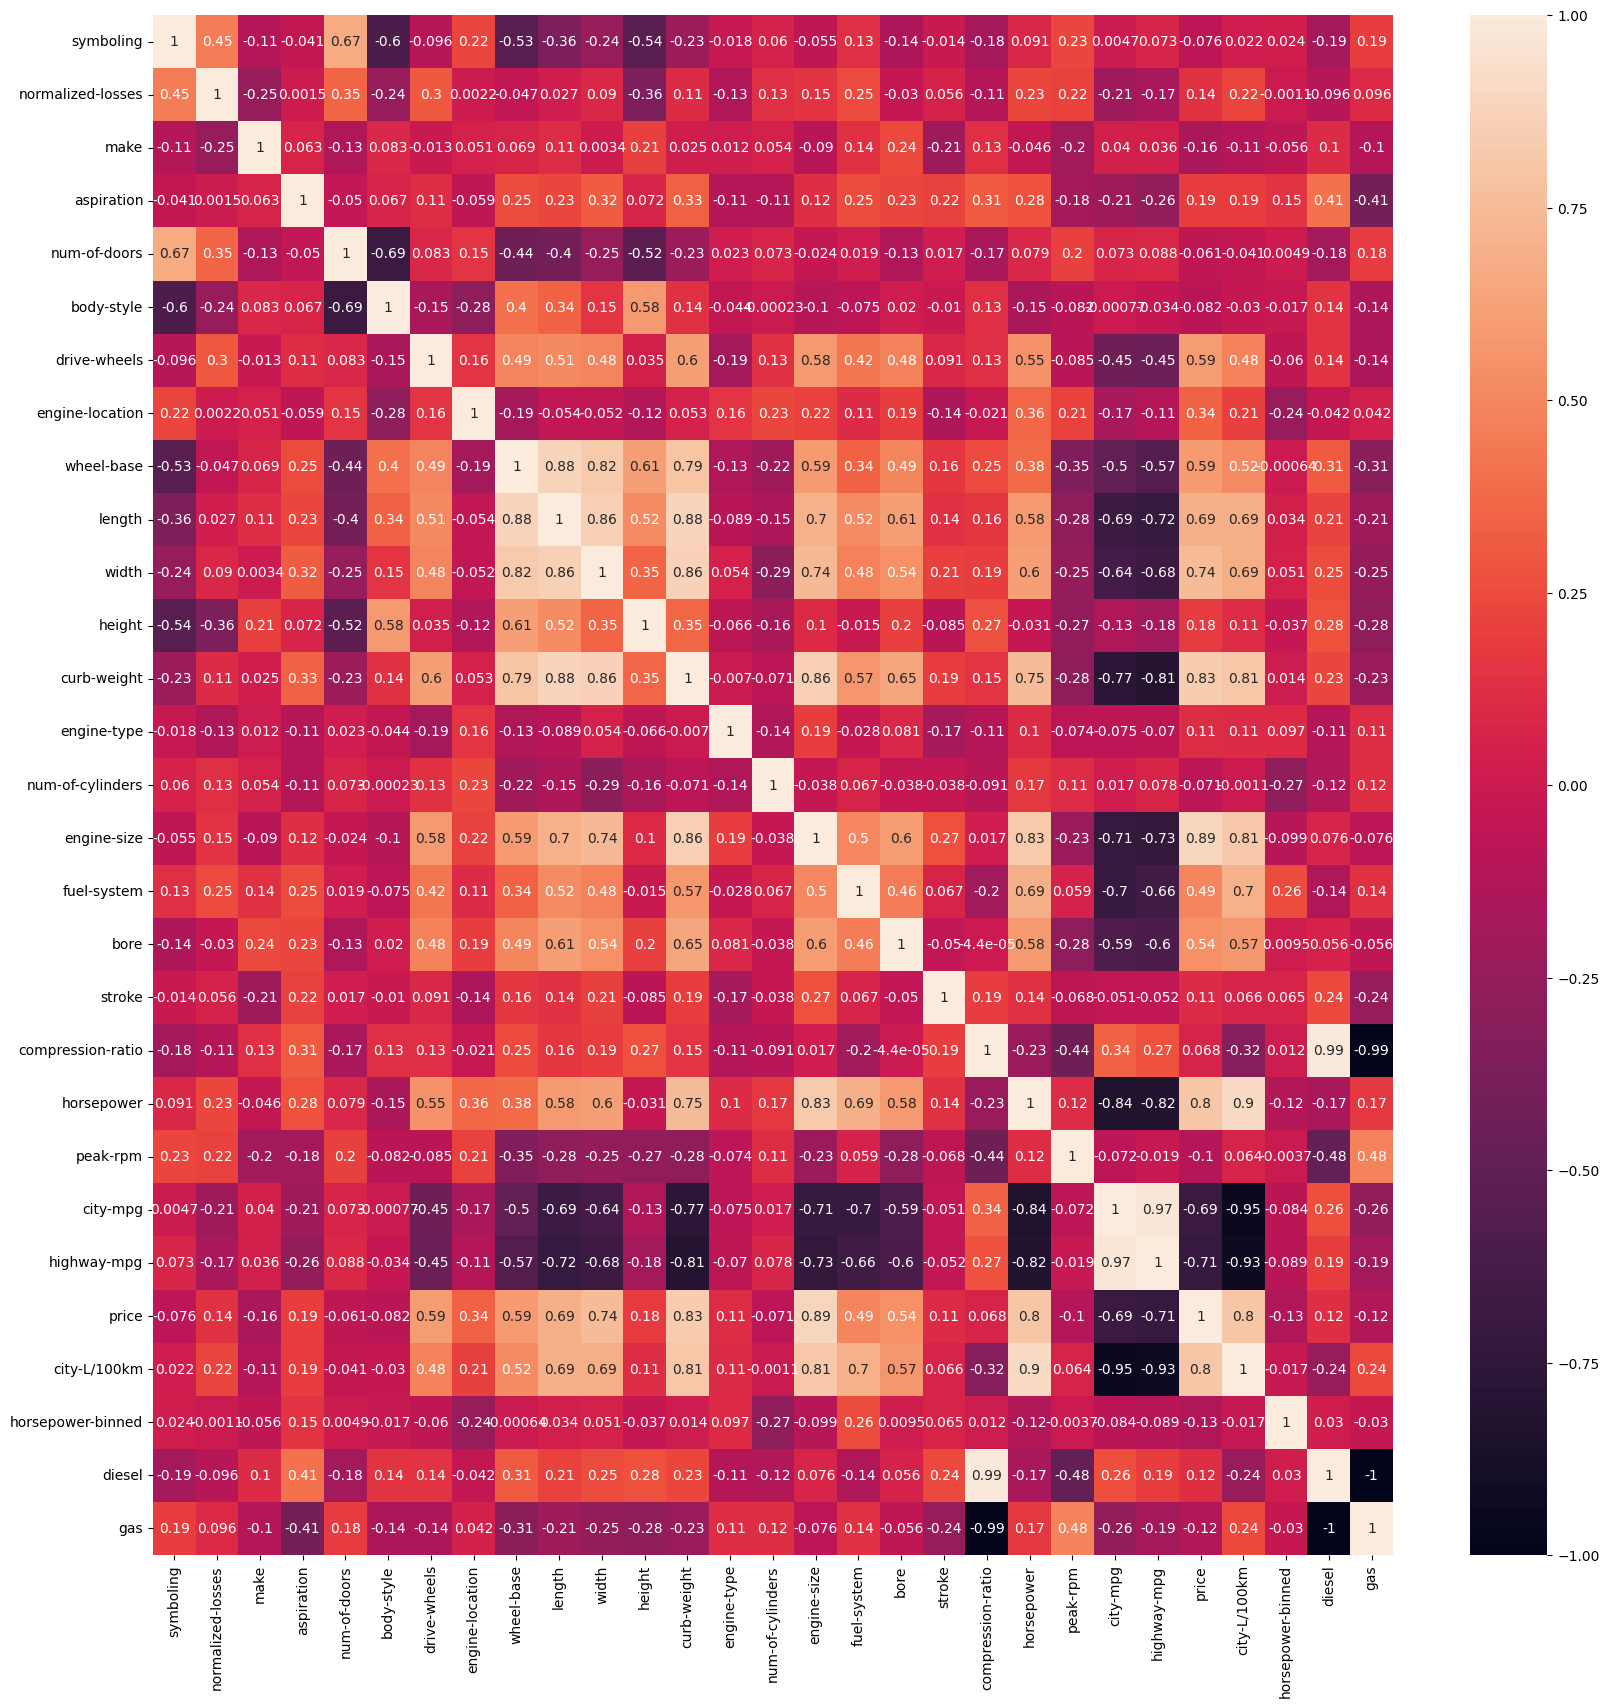

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)

# Univariate Regression

In [ ]:
X = df[['highway-mpg']]
Y = df['price']

In [ ]:
X.head()

,highway-mpg
0,27
1,27
2,26
3,30
4,22


In [ ]:
Y.head()

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


(0.0, 48188.057778024086)

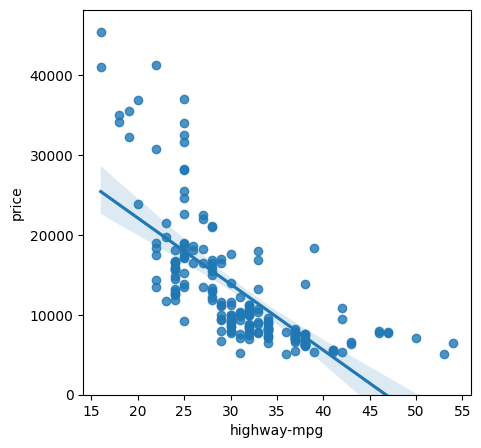

In [ ]:
plt.figure(figsize=(5, 5))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

(0.0, 47910.1030345551)

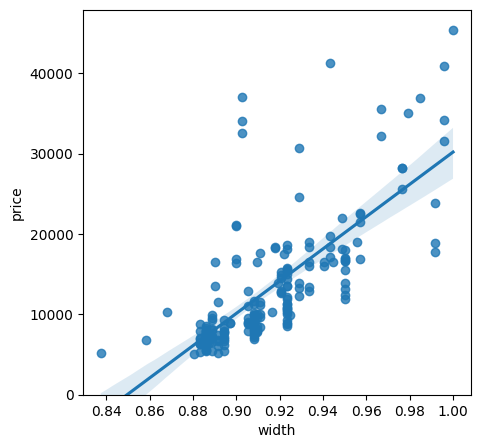

In [ ]:
plt.figure(figsize=(5, 5))
sns.regplot(x="width", y="price", data=df)
plt.ylim(0,)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(X, Y)

LinearRegression()

In [ ]:
model.coef_

array([-826.8385431])

In [ ]:
model.intercept_

np.float64(38654.93741138215)

In [ ]:
# x * m + c
27 * model.coef_ + model.intercept_

array([16330.29674774])

In [ ]:
model.predict(X.head())

array([16330.29674774, 16330.29674774, 17157.13529083, 13849.78111844,
       20464.48946323])

In [ ]:
Y.head()

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


In [ ]:
X.iloc[0]

,0
highway-mpg,27


In [ ]:
X.iloc[0], Y[0], model.predict([X.iloc[0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


(highway-mpg    27
 Name: 0, dtype: int64,
 np.float64(13495.0),
 array([16330.29674774]))

In [ ]:
model.score(X, Y)

0.5005084846139531

In [ ]:
# Accuracy metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def error_metrics(y, y_hat):
  print("MSE", mean_squared_error(y, y_hat))
  print("MAE", mean_absolute_error(y, y_hat))
  print("Score", r2_score(y, y_hat))

In [ ]:
y_hat = model.predict(X)
error_metrics(Y, y_hat)

MSE 30825942.551791985
MAE 3992.859089870485
Score 0.5005084846139531


### R Squared Score

![](https://miro.medium.com/v2/resize:fit:1400/1*_HbrAW-tMRBli6ASD5Bttw.png)

In [ ]:
# smart
def r2_score(y, y_hat):
  return 1 - np.var(y - y_hat) / np.var(y)

In [ ]:
r2_score(Y, y_hat)

0.5005084846139529

In [ ]:
lr = LinearRegression()
X = df[['highway-mpg']]
Y = df['price']
lr.fit(X,Y)
lr.score(X, Y)

0.5005084846139531

In [ ]:
lr = LinearRegression()
X = df[['engine-size']]
Y = df['price']
lr.fit(X,Y)
lr.score(X, Y)

0.7907921777729757

## Task 1

Fit the model using top 3 correlated feature and print the error_metrics

In [ ]:
# 1

In [ ]:
# 2

In [ ]:
# 3

# Multivariate Linear Regression

In [ ]:
df.corr()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
symboling,1.000000,0.453423,-0.112559,-0.041190,0.667915,-0.596097,-0.096449,0.223380,-0.533112,-0.359883,...,-0.180275,0.090778,0.229436,0.004688,0.073359,-0.076420,0.021612,0.023676,-0.192544,0.192544
normalized-losses,0.453423,1.000000,-0.245565,0.001467,0.349368,-0.242336,0.303581,0.002222,-0.046971,0.027234,...,-0.112288,0.226654,0.215903,-0.208695,-0.166772,0.138183,0.223308,-0.001090,-0.096487,0.096487
make,-0.112559,-0.245565,1.000000,0.063259,-0.127942,0.083498,-0.012847,0.051402,0.068818,0.112173,...,0.132276,-0.046322,-0.196158,0.040396,0.035571,-0.155926,-0.105835,-0.055537,0.104058,-0.104058
aspiration,-0.041190,0.001467,0.063259,1.000000,-0.050239,0.066884,0.111344,-0.059139,0.254382,0.231671,...,0.307550,0.276945,-0.179876,-0.212686,-0.264393,0.190811,0.191686,0.147935,0.405970,-0.405970
num-of-doors,0.667915,0.349368,-0.127942,-0.050239,1.000000,-0.689999,0.083101,0.148555,-0.444147,-0.403186,...,-0.169648,0.079041,0.200280,0.073095,0.087902,-0.061182,-0.041360,0.004903,-0.180226,0.180226
body-style,-0.596097,-0.242336,0.083498,0.066884,-0.689999,1.000000,-0.149712,-0.281519,0.401525,0.342662,...,0.131966,-0.151380,-0.081741,-0.000774,-0.034378,-0.081654,-0.029537,-0.017354,0.144577,-0.144577
drive-wheels,-0.096449,0.303581,-0.012847,0.111344,0.083101,-0.149712,1.000000,0.156170,0.489942,0.509957,...,0.125247,0.552148,-0.084604,-0.445250,-0.451451,0.594892,0.481235,-0.060104,0.144323,-0.144323
engine-location,0.223380,0.002222,0.051402,-0.059139,0.148555,-0.281519,0.156170,1.000000,-0.191048,-0.053633,...,-0.020755,0.362800,0.214045,-0.166195,-0.109681,0.340156,0.206294,-0.238047,-0.042028,0.042028
wheel-base,-0.533112,-0.046971,0.068818,0.254382,-0.444147,0.401525,0.489942,-0.191048,1.000000,0.876945,...,0.248383,0.381984,-0.351925,-0.496565,-0.566948,0.591956,0.517050,-0.000638,0.305889,-0.305889
length,-0.359883,0.027234,0.112173,0.231671,-0.403186,0.342662,0.509957,-0.053633,0.876945,1.000000,...,0.156926,0.583073,-0.280397,-0.686142,-0.715124,0.689466,0.690579,0.033677,0.212484,-0.212484


In [ ]:
lr = LinearRegression()
X = df[['wheel-base', 'length','width','curb-weight','engine-size','fuel-system', 'bore','horsepower','city-L/100km']]
Y = df['price']
lr.fit(X,Y)
lr.score(X, Y)

0.8293914815681079

In [ ]:
y_true = Y
y_pred = lr.predict(X)

In [ ]:
error_metrics(y_true, y_pred)

MSE 10529044.49030159
MAE 2291.1025917219827
Score 0.8293914815681079


## Polynomial Regression

<p><b>Polynomial regression</b> is a particular case of the general linear regression model or multiple linear regression models.</p>
<p>We get non-linear relationships by squaring or setting higher-order terms of the predictor variables.</p>

<p>There are different orders of polynomial regression:</p>

<center><b>Quadratic - 2nd order</b></center>
$$
Yhat = a + b_1 X^2 +b_2 X^2
$$


<center><b>Cubic - 3rd order</b></center>
$$
Yhat = a + b_1 X^2 +b_2 X^2 +b_3 X^3\\
$$


<center><b>Higher order</b>:</center>
$$
Y = a + b_1 X^2 +b_2 X^2 +b_3 X^3 ....\\
$$

In [ ]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

In [ ]:
x = df['highway-mpg']
y = df['price']

In [ ]:
x

,highway-mpg
0,27
1,27
2,26
3,30
4,22
...,...
196,28
197,25
198,23
199,27


In [ ]:
import numpy as np
x_new = np.linspace(15, 55, 100)
x_new

array([15.        , 15.4040404 , 15.80808081, 16.21212121, 16.61616162,
       17.02020202, 17.42424242, 17.82828283, 18.23232323, 18.63636364,
       19.04040404, 19.44444444, 19.84848485, 20.25252525, 20.65656566,
       21.06060606, 21.46464646, 21.86868687, 22.27272727, 22.67676768,
       23.08080808, 23.48484848, 23.88888889, 24.29292929, 24.6969697 ,
       25.1010101 , 25.50505051, 25.90909091, 26.31313131, 26.71717172,
       27.12121212, 27.52525253, 27.92929293, 28.33333333, 28.73737374,
       29.14141414, 29.54545455, 29.94949495, 30.35353535, 30.75757576,
       31.16161616, 31.56565657, 31.96969697, 32.37373737, 32.77777778,
       33.18181818, 33.58585859, 33.98989899, 34.39393939, 34.7979798 ,
       35.2020202 , 35.60606061, 36.01010101, 36.41414141, 36.81818182,
       37.22222222, 37.62626263, 38.03030303, 38.43434343, 38.83838384,
       39.24242424, 39.64646465, 40.05050505, 40.45454545, 40.85858586,
       41.26262626, 41.66666667, 42.07070707, 42.47474747, 42.87

 
-826.8 x + 3.865e+04


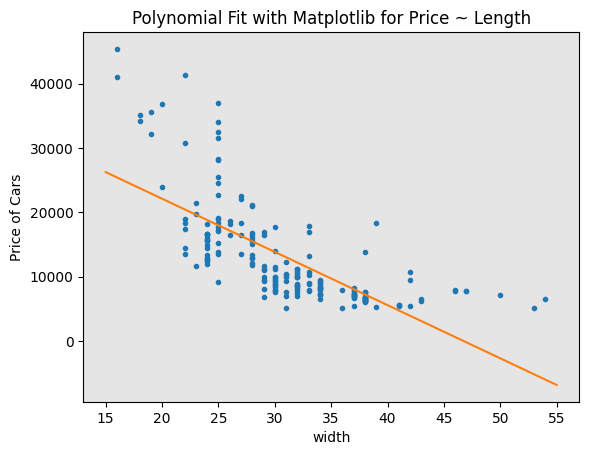

In [ ]:
# under fit
f = np.polyfit(x, y, 1)
p = np.poly1d(f)
print(p)
PlotPolly(p, x, y, 'width')

        3       2
-1.541 x + 205 x - 9067 x + 1.404e+05


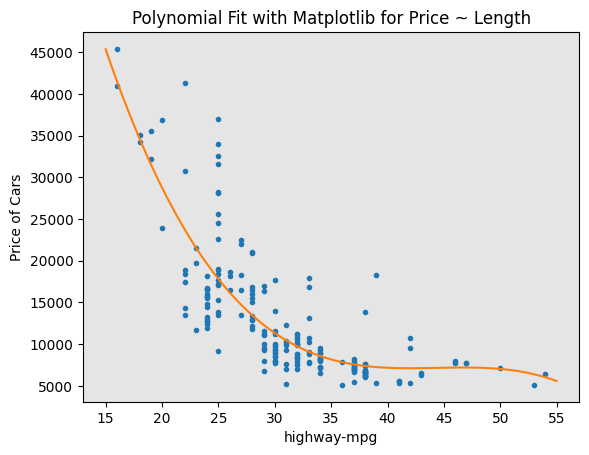

In [ ]:
# good fit
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)
PlotPolly(p, x, y, 'highway-mpg')

In [ ]:
f

array([-1.54103878e+00,  2.05042094e+02, -9.06737826e+03,  1.40428290e+05])

            10             9            8          7         6
-4.733e-08 x  + 1.775e-05 x - 0.002946 x + 0.2847 x - 17.74 x
          5            4             3             2
 + 743.3 x - 2.12e+04 x + 4.061e+05 x - 4.992e+06 x + 3.552e+07 x - 1.11e+08


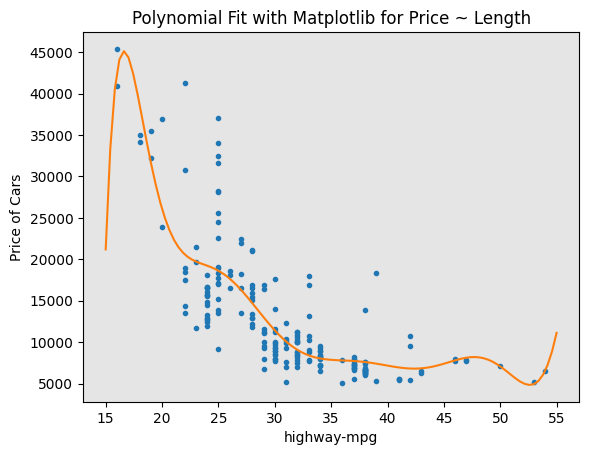

In [ ]:
# over fit
f = np.polyfit(x, y, 10)
p = np.poly1d(f)
print(p)
PlotPolly(p, x, y, 'highway-mpg')

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [ ]:
X = df[['wheel-base', 'length','width','curb-weight','engine-size','fuel-system', 'bore','horsepower','city-L/100km']]
Y = df['price']

In [ ]:
X.iloc[0]

,0
wheel-base,88.600000
length,0.811148
width,0.890278
curb-weight,2548.000000
engine-size,130.000000
fuel-system,4.000000
bore,3.470000
horsepower,111.000000
city-L/100km,11.190476


In [ ]:
X.shape

(196, 9)

In [ ]:
X.iloc[0]

,0
wheel-base,88.600000
length,0.811148
width,0.890278
curb-weight,2548.000000
engine-size,130.000000
fuel-system,4.000000
bore,3.470000
horsepower,111.000000
city-L/100km,11.190476


In [ ]:
X_pr=pr.fit_transform(X)

In [ ]:
X_pr.shape

(196, 55)

In [ ]:
X_pr[0]

array([1.00000000e+00, 8.86000000e+01, 8.11148486e-01, 8.90277778e-01,
       2.54800000e+03, 1.30000000e+02, 4.00000000e+00, 3.47000000e+00,
       1.11000000e+02, 1.11904762e+01, 7.84996000e+03, 7.18677559e+01,
       7.88786111e+01, 2.25752800e+05, 1.15180000e+04, 3.54400000e+02,
       3.07442000e+02, 9.83460000e+03, 9.91476190e+02, 6.57961867e-01,
       7.22147472e-01, 2.06680634e+03, 1.05449303e+02, 3.24459395e+00,
       2.81468525e+00, 9.00374820e+01, 9.07713782e+00, 7.92594522e-01,
       2.26842778e+03, 1.15736111e+02, 3.56111111e+00, 3.08926389e+00,
       9.88208333e+01, 9.96263228e+00, 6.49230400e+06, 3.31240000e+05,
       1.01920000e+04, 8.84156000e+03, 2.82828000e+05, 2.85133333e+04,
       1.69000000e+04, 5.20000000e+02, 4.51100000e+02, 1.44300000e+04,
       1.45476190e+03, 1.60000000e+01, 1.38800000e+01, 4.44000000e+02,
       4.47619048e+01, 1.20409000e+01, 3.85170000e+02, 3.88309524e+01,
       1.23210000e+04, 1.24214286e+03, 1.25226757e+02])

In [ ]:
lr = LinearRegression()
lr.fit(X,Y)
lr.score(X, Y)

0.8293914815681079

In [ ]:
lr = LinearRegression()
lr.fit(X_pr,Y)
lr.score(X_pr, Y)
# after polynomial conversion accuracy had improved

0.9412042911380797

In [ ]:
y_pred = lr.predict(X_pr)

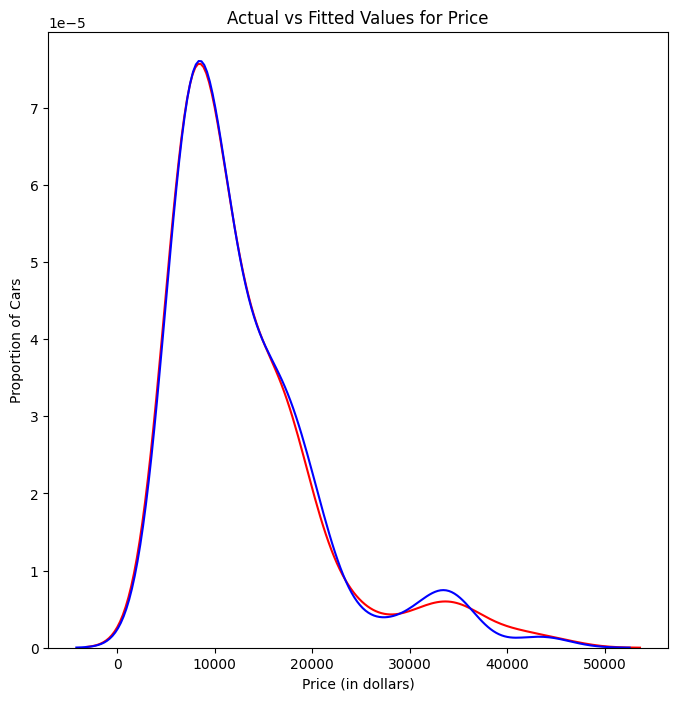

In [ ]:
plt.figure(figsize=(8, 8))

ax1 = sns.kdeplot(df['price'], color="r", label="Actual Value") # hist=True
sns.kdeplot(y_pred, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

# Polynomial Regression with Normalization


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
X = df[['wheel-base', 'length','width','curb-weight','engine-size','fuel-system', 'bore','horsepower','city-L/100km']]
Y = df['price']

In [ ]:
X.iloc[0]

,0
wheel-base,88.600000
length,0.811148
width,0.890278
curb-weight,2548.000000
engine-size,130.000000
fuel-system,4.000000
bore,3.470000
horsepower,111.000000
city-L/100km,11.190476


In [ ]:
norm = MinMaxScaler()
pr = PolynomialFeatures(2)

In [ ]:
X_norm = norm.fit_transform(X)
X_norm.shape

(196, 9)

In [ ]:
X_norm[0]

array([0.05830904, 0.41343284, 0.32478632, 0.41117145, 0.27935223,
       0.66666667, 0.66428571, 0.39622642, 0.53333333])

In [ ]:
X_norm_pr = pr.fit_transform(X_norm)
X_norm_pr.shape

(196, 55)

In [ ]:
# without Norm
lr = LinearRegression()
lr.fit(X,Y)
lr.score(X, Y)
y_hat = lr.predict(X)
error_metrics(Y, y_hat)

MSE 10529044.49030159
MAE 2291.1025917219827
Score 0.8293914815681079


In [ ]:
# with norm
lr_norm = LinearRegression()
lr_norm.fit(X_norm,Y)
lr_norm.score(X_norm, Y)
y_hat = lr_norm.predict(X_norm)
error_metrics(Y, y_hat)

MSE 10529044.490301594
MAE 2291.1025917220213
Score 0.8293914815681078


In [ ]:
# with norm and poly
lr_pr = LinearRegression()
lr_pr.fit(X_norm_pr,Y)
lr_pr.score(X_norm_pr, Y)
y_hat = lr_pr.predict(X_norm_pr)
error_metrics(Y, y_hat)

MSE 3628556.417557104
MAE 1321.9630488620937
Score 0.9412042911380822


# Test Train Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm_pr, Y, test_size=0.20, random_state=42)

In [ ]:
print(X_norm_pr.shape)
print(X_train.shape)
print(X_test.shape)

(196, 55)
(156, 55)
(40, 55)


In [ ]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr.score(X_train,y_train)

0.9536200959327668

In [ ]:
# Training Score
y_hat = lr.predict(X_train)
error_metrics(y_train, y_hat)

MSE 2615217.5081586074
MAE 1143.6785977203153
Score 0.9536200959327668


In [ ]:
# Testing Score
y_hat = lr.predict(X_test)
error_metrics(y_test, y_hat)

MSE 10679276.956717178
MAE 2061.5202460883766
Score 0.8721123787075695
